# **LDA - Linear Discriminant Analysis**

it is also dimensionality reduction technique but also focuses on class separability.

- mean to be maximum and variance to be minimum

## Finding the n-components

In [ ]:
# min(no_of_features, no_of_classes - 1)

# features -- all the input columns -- all the cols except the target
# classes -- no of target labels

In [ ]:
# if we have 10 features and 12 classes

# min(10, 12-1) ==> min(10,11) ==>10

# n_components = 10

In [ ]:
# in a dataset we have 12 independent columns and
# 1 target column and we have 5 classes

# n_components = 4

In [ ]:
# in the dataset we have 30 columns and
# in target column we have 15 classes

# n_components = 14

In [ ]:
# in the dataset we have 15 columns and
# in target column we have 21 classes

# if we have 15 cols it means
# 14 are independent and 1 is target

# n_components = 14

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

In [ ]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [ ]:
x = iris.data
y = iris.target

In [ ]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
x.shape

(150, 4)

In [ ]:
df = pd.DataFrame(x, columns = ["A","B","C","D"])

In [ ]:
df

,A,B,C,D
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
import plotly.express as px

fig = px.scatter_3d(df, x= "A", y = "B", z = "C", color = y, title = "3d Scatter Plot")
fig.show()

## Lets create a model without using LDA and lets observe the accurarcy

In [ ]:
pd.DataFrame(x)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
pd.DataFrame(y)

,0
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [ ]:
type(x)

numpy.ndarray

In [ ]:
type(y)

numpy.ndarray

In [ ]:
# splitting into training and testing

# logistic regression model

# 7:54

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8, random_state=3)

In [ ]:
x_train.shape,x_test.shape

((120, 4), (30, 4))

In [ ]:
y_train.shape,y_test.shape

((120,), (30,))

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter = 1000)

In [ ]:
log_model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = log_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

1.0

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
# n_components = ?

# min(features, classes -1)

# min(4, 3-1) ==> min(4,2) ==> 2

In [ ]:
lda = LinearDiscriminantAnalysis(n_components = 2)

In [ ]:
x_lda = lda.fit_transform(x,y)

# LDA is supervised -- it needs y class labels to decide how to transform the data.


In [ ]:
pd.DataFrame(x_lda)

,0,1
0,8.061800,-0.300421
1,7.128688,0.786660
2,7.489828,0.265384
3,6.813201,0.670631
4,8.132309,-0.514463
...,...,...
145,-5.645003,-1.677717
146,-5.179565,0.363475
147,-4.967741,-0.821141
148,-5.886145,-2.345091


In [ ]:
x_train1,x_test1,y_train1,y_test1 = train_test_split(x_lda,y, test_size =0.2, random_state=3)

In [ ]:
x_train1.shape, x_test1.shape

((120, 2), (30, 2))

In [ ]:
y_train1.shape, y_test1.shape

((120,), (30,))

In [ ]:
model1 = LogisticRegression(max_iter = 200)

In [ ]:
model1.fit(x_train1,y_train1)

LogisticRegression(max_iter=200)

In [ ]:
y_pred1 = model1.predict(x_test1)

In [ ]:
accuracy_score(y_test1,y_pred1)

1.0

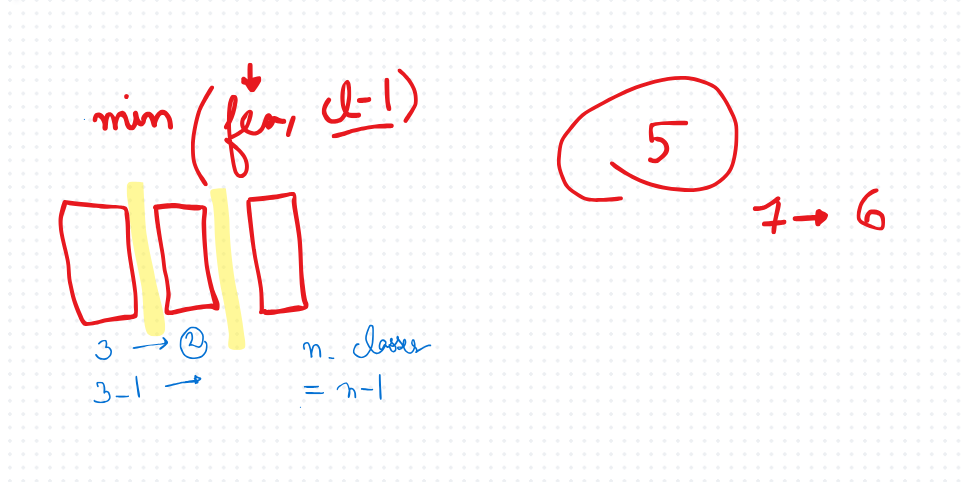

In [ ]:
# we can separate n classes at most by n-1 directions or n-1 components
# but if we have more classes as compared to the features
# we will be contradicting the whole purpose of our LDA that is why
# we use min of features or classes-1

# eg. if we have 5 features and 7 classes we cannot create 6 LDA components as
# no of features we are having is less than that so we will be creating lda with 5 components only

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
digits = load_digits()

In [ ]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
print(digits['DESCR'])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

Get the input and output values in the variables

In [ ]:
x = digits.data
y = digits.target

splitting into training and testing

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2, random_state =62)

In [ ]:
x_train.shape,x_test.shape

((1437, 64), (360, 64))

In [ ]:
y_train.shape,y_test.shape

((1437,), (360,))

scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

LDA

In [ ]:
# min(features, classes-1)

min(64,10-1)

9

In [ ]:
# n_components = 9

In [ ]:
LDA = LinearDiscriminantAnalysis(n_components=9)

In [ ]:
x_train = LDA.fit_transform(x_train,y_train)
x_test = LDA.transform(x_test)

In [ ]:
# create a model with logistic regression check accuracy
# create a model with Random forest and again check accuracy

# -- 5 mins

In [ ]:
log = LogisticRegression()

In [ ]:
log.fit(x_train,y_train)
y_pred = log.predict(x_test)
accuracy_score(y_test,y_pred)

0.9333333333333333

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier()

In [ ]:
rf.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred1 = rf.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred1)

0.9388888888888889

In [ ]:
# overfitting -- when it crams the patterns-- just learning the values
# it will perform well on training data and will perform not that well on testing or unseen data